# ML Pipeline

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import PowerTransformer
from sklearn.neighbors import LocalOutlierFactor

from sklearn.model_selection import(
    train_test_split,
    StratifiedKFold
)
from sklearn.svm import SVC

from sklearn.metrics import(
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_curve, 
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from itertools import product

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv("Datasets/Botswana_GAD_eGeMAPS_QBF.csv")

# Modify GAD7 binary classification
df['Anxiety_Binary'] = df['GAD7_Total'].apply(lambda x: 'Anxious' if x >= 5 else 'Non-Anxious')

# Deep copy the dataset for machine learning
ml_df = df.copy()
ml_df.drop(columns=['SessionID', 'QBF_Name', 'Sex', 'Age'], inplace=True)

# Encode anxiety categories
anxiety_category_map = {"Minimal": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
anxiety_binary_map = {"Non-Anxious": 0, "Anxious": 1}
ml_df['Anxiety_Category'] = ml_df['Anxiety_Category'].map(anxiety_category_map)
ml_df['Anxiety_Binary'] = ml_df['Anxiety_Binary'].map(anxiety_binary_map)

# Acoustic Features
metadata_cols = [
    'SessionID', 'QBF_Name', 'Sex', 'Age', 'Health', 'Health_Binary',
    'Country', 'GAD7_Total', 'Anxiety_Category', 'Anxiety_Binary'
]
acoustic_features = [col for col in ml_df.columns if col not in metadata_cols]
stddev_features = [col for col in acoustic_features if 'stddev' in col.lower()]

# Data preparation
X = ml_df[acoustic_features]
y = ml_df['Anxiety_Binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Outlier detection
def IQR_OutlierDetection(X, lower_quantile=0.025, upper_quantile=0.975):
    Q1 = X.quantile(lower_quantile)
    Q3 = X.quantile(upper_quantile)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - IQR
    upper_bound = Q3 + IQR
    
    mask_inlier_df = (X >= lower_bound) & (X <= upper_bound)
    
    mask_inlier = mask_inlier_df.all(axis=1)
    
    return mask_inlier

def LOF_OutlierDetection(X, n_neighbors=5, contamination=0.05, algorithm='auto', metric='manhattan'):
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        algorithm=algorithm,
        metric=metric,
        leaf_size=30,
        novelty=False)
    y_pred = lof.fit_predict(X)

    mask_lof_inliers = y_pred == 1
    # mask_lof_outliers = y_pred == -1
    
    return mask_lof_inliers

# Define the pipeline
pipeline = ImbPipeline([
    ("yjpt", PowerTransformer(method='yeo-johnson', standardize=True)),
    ("oversampling", SMOTE(random_state=42)),
    ("clf", SVC(kernel="rbf", probability=False, random_state=42))
])

# Define the parameter grid
param_grid = {
    'oversampling__k_neighbors': [3, 5],
    'clf__C': np.logspace(-3, 3, 7),
    'clf__gamma': np.logspace(-4, 3, 8)
}

# Set up stratified K-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generate all parameter combinations
param_combinations = list(product(
    param_grid['oversampling__k_neighbors'],
    param_grid['clf__C'],
    param_grid['clf__gamma']
))

In [3]:
# Cross-validation folds with outlier removal (data leakage free)
def clean_folds(method, cv, X_train, y_train):
    clean_folds = []
    for train_index, val_index in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
        if method == 'LOF':
            mask_inliers = LOF_OutlierDetection(X_fold_train)
        elif method == 'IQR':
            mask_inliers = IQR_OutlierDetection(X_fold_train)
        else:
            raise ValueError("Unsupported outlier detection method.")
        X_fold_train_inliers = X_fold_train[mask_inliers]
        y_fold_train_inliers = y_fold_train[mask_inliers]
        clean_folds.append((X_fold_train_inliers, y_fold_train_inliers, X_fold_val, y_fold_val))
    return clean_folds

In [4]:
# Manual grid search
def manual_grid_search(cleaned_folds, param_combinations, pipeline):
    # Custom grid search loop
    best_auc = -np.inf  # Initialize best AUC score to determine the best model
    mean_fpr = np.linspace(0, 1, 100)  # Common FPR points for interpolation

    for params in param_combinations:
        # Unpack parameters
        oversampling_k_neighbors, clf_c, clf_gamma = params
        
        # Set pipeline parameters
        pipeline.set_params(
            oversampling__k_neighbors=oversampling_k_neighbors,
            clf__C=clf_c,
            clf__gamma=clf_gamma
        )
        
        # Initialize metrics storage
        f1_scores, precision_scores, recall_scores, balanced_accuracy_scores = [], [], [], []
        interpolated_tprs, fprs, aucs = [], [], []
        
        # Initialize lists to collect true labels and scores for PR curve
        current_y_true, current_y_scores = [], []

        # Perform cross-validation
        for X_fold_train_inliers, y_fold_train_inliers, X_fold_val, y_fold_val in cleaned_folds:
            # Fit, predict, and score
            pipeline.fit(X_fold_train_inliers, y_fold_train_inliers)
            y_fold_pred = pipeline.predict(X_fold_val)
            y_fold_scores = pipeline.decision_function(X_fold_val)

            # Evaluate the pipeline
            f1_scores.append(f1_score(y_fold_val, y_fold_pred, average='binary'))
            precision_scores.append(precision_score(y_fold_val, y_fold_pred, average='binary', zero_division=0))
            recall_scores.append(recall_score(y_fold_val, y_fold_pred, average='binary', zero_division=0))
            balanced_accuracy_scores.append(balanced_accuracy_score(y_fold_val, y_fold_pred))

            # Compute AUC
            fpr, tpr, _ = roc_curve(y_fold_val, y_fold_scores)
            auc_score = auc(fpr, tpr)
            aucs.append(auc_score)
            
            # Interpolate TPR to common FPR points for ROC curve
            interpolated_tpr = np.interp(mean_fpr, fpr, tpr)
            interpolated_tpr[0] = 0.0
            interpolated_tprs.append(interpolated_tpr)
            fprs.append(fpr)
            
            # For future PR curve
            current_y_true.append(y_fold_val)
            current_y_scores.append(y_fold_scores)
            
            print(f"Balance: {len(y_fold_train_inliers[y_fold_train_inliers==1])/len(y_fold_train_inliers):.2f}, fold f1-score: {f1_scores[-1]:.4f}, precision: {precision_scores[-1]:.4f}, recall: {recall_scores[-1]:.4f}, balanced accuracy: {balanced_accuracy_scores[-1]:.4f}, AUC: {auc_score:.4f}")

        # Compute average scores
        avg_f1 = np.mean(f1_scores)
        avg_precision = np.mean(precision_scores)
        avg_recall = np.mean(recall_scores)
        avg_auc = np.mean(aucs)
        avg_balanced_accuracy = np.mean(balanced_accuracy_scores)
        print(f"Params: {params} => Avg F1: {avg_f1:.4f}, Avg Precision: {avg_precision:.4f}, Avg Recall: {avg_recall:.4f}, Avg AUC: {avg_auc:.4f}, Avg Balanced Accuracy: {avg_balanced_accuracy:.4f}")
        
        # Update best scores and parameters
        if avg_auc > best_auc:
            best_auc = avg_auc
            best_model_metrics = {
                "best_auc": avg_auc,
                "best_f1_score": avg_f1,
                "best_precision_score": avg_precision,
                "best_recall_score": avg_recall,
                "best_balanced_accuracy_score": avg_balanced_accuracy,
                "best_interpolated_tprs": interpolated_tprs,
                "best_params": params,
                "best_y_true": current_y_true,
                "best_y_scores": current_y_scores
            }
    
    # Output the best parameters and scores
    print("Best Averaged AUC Score:", best_model_metrics["best_auc"])
    print("Best Averaged F1 Score:", best_model_metrics["best_f1_score"])
    print("Best Averaged Precision Score:", best_model_metrics["best_precision_score"])
    print("Best Averaged Recall Score:", best_model_metrics["best_recall_score"])
    print("Best Averaged Balanced Accuracy Score:", best_model_metrics["best_balanced_accuracy_score"])
    print("Best Parameters:", best_model_metrics["best_params"])
    
    return best_model_metrics

In [5]:
clean_folds_iqr = clean_folds('IQR', cv, X_train, y_train)
best_model_metrics_iqr = manual_grid_search(clean_folds_iqr, param_combinations, pipeline)

Balance: 0.56, fold f1-score: 0.2381, precision: 0.3333, recall: 0.1852, balanced accuracy: 0.3752, AUC: 0.4283
Balance: 0.55, fold f1-score: 0.5818, precision: 0.5714, recall: 0.5926, balanced accuracy: 0.5354, AUC: 0.5491
Balance: 0.55, fold f1-score: 0.4082, precision: 0.4545, recall: 0.3704, balanced accuracy: 0.4125, AUC: 0.4259
Balance: 0.56, fold f1-score: 0.5600, precision: 0.6087, recall: 0.5185, balanced accuracy: 0.5547, AUC: 0.5993
Balance: 0.57, fold f1-score: 0.6349, precision: 0.5556, recall: 0.7407, balanced accuracy: 0.5067, AUC: 0.5960
Params: (3, np.float64(0.001), np.float64(0.0001)) => Avg F1: 0.4846, Avg Precision: 0.5047, Avg Recall: 0.4815, Avg AUC: 0.5197, Avg Balanced Accuracy: 0.4769
Balance: 0.56, fold f1-score: 0.2727, precision: 0.3529, recall: 0.2222, balanced accuracy: 0.3720, AUC: 0.4332
Balance: 0.55, fold f1-score: 0.5714, precision: 0.5517, recall: 0.5926, balanced accuracy: 0.5137, AUC: 0.5072
Balance: 0.55, fold f1-score: 0.4444, precision: 0.4444,

In [6]:
clean_folds_lof = clean_folds('LOF', cv, X_train, y_train)
best_model_metrics_lof = manual_grid_search(clean_folds_lof, param_combinations, pipeline)

Balance: 0.56, fold f1-score: 0.3750, precision: 0.4286, recall: 0.3333, balanced accuracy: 0.4058, AUC: 0.4356
Balance: 0.56, fold f1-score: 0.5385, precision: 0.5600, recall: 0.5185, balanced accuracy: 0.5201, AUC: 0.5411
Balance: 0.56, fold f1-score: 0.5490, precision: 0.5833, recall: 0.5185, balanced accuracy: 0.5320, AUC: 0.4983
Balance: 0.54, fold f1-score: 0.5660, precision: 0.5769, recall: 0.5556, balanced accuracy: 0.5278, AUC: 0.6271
Balance: 0.56, fold f1-score: 0.7037, precision: 0.7037, recall: 0.7037, balanced accuracy: 0.6700, AUC: 0.6246
Params: (3, np.float64(0.001), np.float64(0.0001)) => Avg F1: 0.5464, Avg Precision: 0.5705, Avg Recall: 0.5259, Avg AUC: 0.5453, Avg Balanced Accuracy: 0.5311
Balance: 0.56, fold f1-score: 0.3830, precision: 0.4500, recall: 0.3333, balanced accuracy: 0.4275, AUC: 0.4436
Balance: 0.56, fold f1-score: 0.5385, precision: 0.5600, recall: 0.5185, balanced accuracy: 0.5201, AUC: 0.5185
Balance: 0.56, fold f1-score: 0.5200, precision: 0.5652,

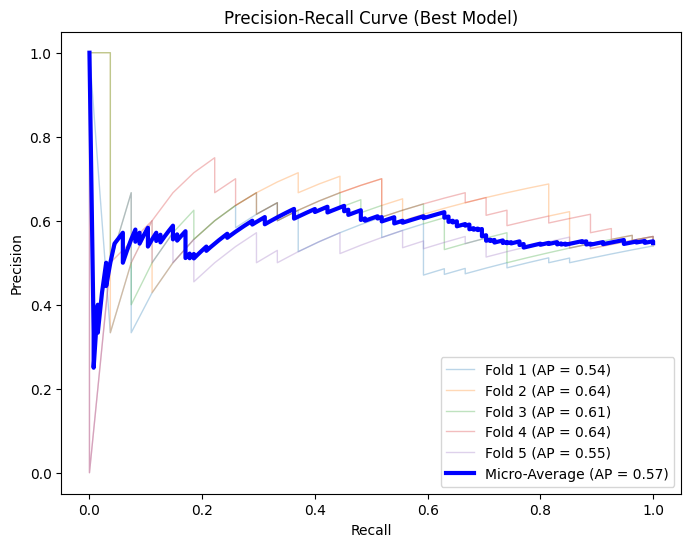

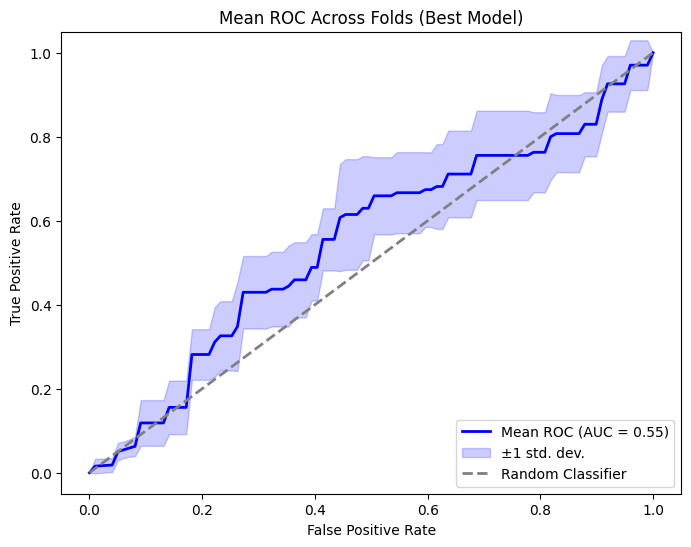

In [7]:
# Visualization for the best model (IQR outlier removal)
best_auc = best_model_metrics_iqr["best_auc"]
best_f1_score = best_model_metrics_iqr["best_f1_score"]
best_precision_score = best_model_metrics_iqr["best_precision_score"]
best_recall_score = best_model_metrics_iqr["best_recall_score"]
best_balanced_accuracy_score = best_model_metrics_iqr["best_balanced_accuracy_score"]
best_interpolated_tprs = best_model_metrics_iqr["best_interpolated_tprs"]
best_params = best_model_metrics_iqr["best_params"]
best_y_true = best_model_metrics_iqr["best_y_true"]
best_y_scores = best_model_metrics_iqr["best_y_scores"]
mean_fpr = np.linspace(0, 1, 100)

# Plot PR curve for the best model
fig, ax = plt.subplots(figsize=(8, 6))

# Plot PR curve for folds
for i in range(len(best_y_true)):
    y_true_fold = best_y_true[i]
    y_scores_fold = best_y_scores[i]
    
    precision, recall, _ = precision_recall_curve(y_true_fold, y_scores_fold)
    fold_ap = average_precision_score(y_true_fold, y_scores_fold)
    
    ax.plot(recall, precision, lw=1, alpha=0.3, label=f'Fold {i+1} (AP = {fold_ap:.2f})')

# Plot global PR curve
y_true_global = np.concatenate(best_y_true)
y_scores_global = np.concatenate(best_y_scores)

precision_global, recall_global, _ = precision_recall_curve(y_true_global, y_scores_global)
ap_global = average_precision_score(y_true_global, y_scores_global)

ax.plot(recall_global, precision_global, color='b', lw=3, label=f'Micro-Average (AP = {ap_global:.2f})')

ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Best Model)')
ax.legend(loc="lower right")
plt.show()

# Plot ROC curve for the best model
mean_tpr = np.mean(best_interpolated_tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_tpr = np.std(best_interpolated_tprs, axis=0)

plt.figure(figsize=(8, 6))
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2)
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color='b', alpha=0.2, label='±1 std. dev.')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Classifier')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mean ROC Across Folds (Best Model)')
plt.legend(loc='lower right')
plt.show()

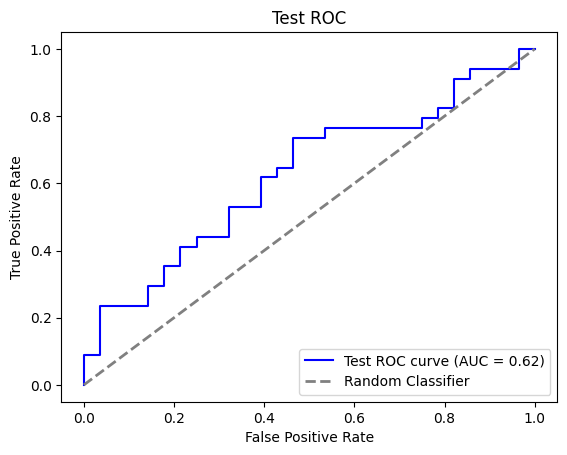

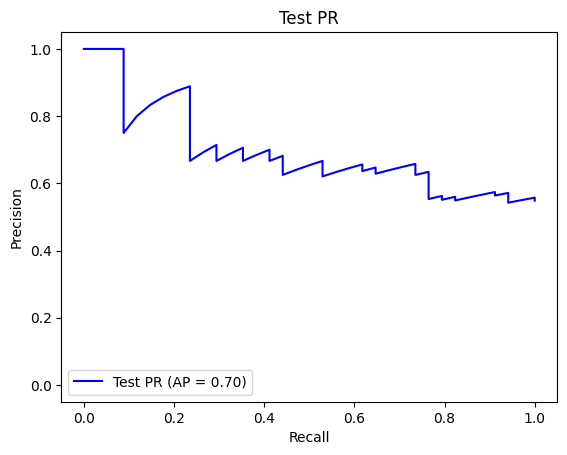

************ Test Results ************
F1 Score: 0.68
Precision Score: 0.65
Recall Score: 0.71
Specificity: 0.54
Balanced Accuracy Score: 0.62
AUC: 0.62
AP: 0.70
Confusion Matrix:
 [[15 13]
 [10 24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.54      0.57        28
           1       0.65      0.71      0.68        34

    accuracy                           0.63        62
   macro avg       0.62      0.62      0.62        62
weighted avg       0.63      0.63      0.63        62



In [8]:
# Final held-out test evaluation using best parameters (IQR outlier removal)
pipeline.set_params(
    oversampling__k_neighbors=best_params[0],
    clf__C=best_params[1],
    clf__gamma=best_params[2]
)
train_inliers = IQR_OutlierDetection(X_train)
X_train_inliers = X_train[train_inliers]
y_train_inliers = y_train[train_inliers]
pipeline.fit(X_train_inliers, y_train_inliers)

y_test_pred = pipeline.predict(X_test)
y_test_scores = pipeline.decision_function(X_test)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_precision = precision_score(y_test, y_test_pred, average='binary', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='binary', zero_division=0)
test_specificity = recall_score(y_test, y_test_pred, average='binary', zero_division=0, pos_label=0)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred)
test_ap = average_precision_score(y_test, y_test_scores)

fpr, tpr, _ = roc_curve(y_test, y_test_scores)
test_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='b', label='Test ROC curve (AUC = {:.2f})'.format(test_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Classifier')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC')
plt.legend(loc='lower right')
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_test_scores)
plt.plot(recall, precision, color='b', label='Test PR (AP = {:.2f})'.format(test_ap))
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Test PR')
plt.legend(loc='lower left')
plt.show()

print("************ Test Results ************")
print(f"F1 Score: {test_f1:.2f}")
print(f"Precision Score: {test_precision:.2f}")
print(f"Recall Score: {test_recall:.2f}")
print(f"Specificity: {test_specificity:.2f}")
print(f"Balanced Accuracy Score: {test_balanced_accuracy:.2f}")
print(f"AUC: {test_auc:.2f}")
print(f"AP: {test_ap:.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred, zero_division=0))

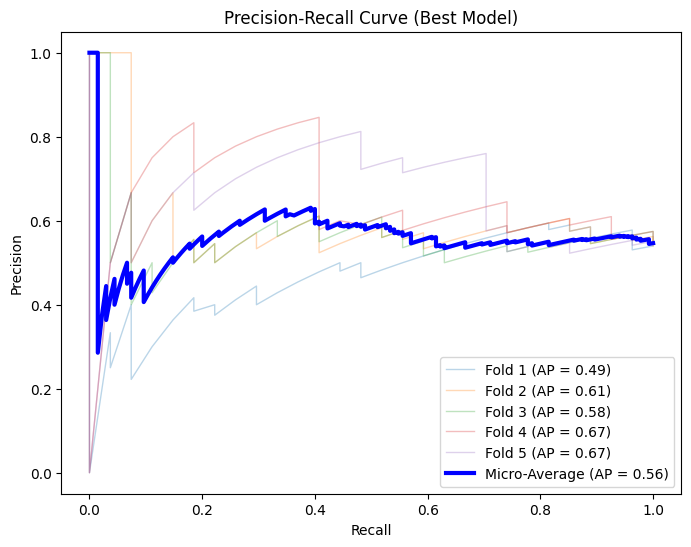

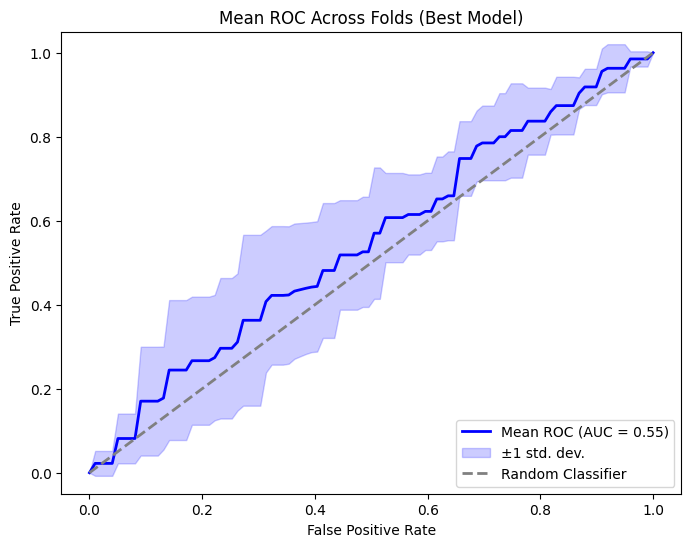

In [9]:
# Visualization for the best model (LOF outlier removal)
best_auc = best_model_metrics_lof["best_auc"]
best_f1_score = best_model_metrics_lof["best_f1_score"]
best_precision_score = best_model_metrics_lof["best_precision_score"]
best_recall_score = best_model_metrics_lof["best_recall_score"]
best_balanced_accuracy_score = best_model_metrics_lof["best_balanced_accuracy_score"]
best_interpolated_tprs = best_model_metrics_lof["best_interpolated_tprs"]
best_params = best_model_metrics_lof["best_params"]
best_y_true = best_model_metrics_lof["best_y_true"]
best_y_scores = best_model_metrics_lof["best_y_scores"]
mean_fpr = np.linspace(0, 1, 100)

# Plot PR curve for the best model
fig, ax = plt.subplots(figsize=(8, 6))

# Plot PR curve for folds
for i in range(len(best_y_true)):
    y_true_fold = best_y_true[i]
    y_scores_fold = best_y_scores[i]
    
    precision, recall, _ = precision_recall_curve(y_true_fold, y_scores_fold)
    fold_ap = average_precision_score(y_true_fold, y_scores_fold)
    
    ax.plot(recall, precision, lw=1, alpha=0.3, label=f'Fold {i+1} (AP = {fold_ap:.2f})')

# Plot global PR curve
y_true_global = np.concatenate(best_y_true)
y_scores_global = np.concatenate(best_y_scores)

precision_global, recall_global, _ = precision_recall_curve(y_true_global, y_scores_global)
ap_global = average_precision_score(y_true_global, y_scores_global)

ax.plot(recall_global, precision_global, color='b', lw=3, label=f'Micro-Average (AP = {ap_global:.2f})')

ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Best Model)')
ax.legend(loc="lower right")
plt.show()

# Plot ROC curve for the best model
mean_tpr = np.mean(best_interpolated_tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_tpr = np.std(best_interpolated_tprs, axis=0)

plt.figure(figsize=(8, 6))
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2)
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color='b', alpha=0.2, label='±1 std. dev.')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Classifier')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mean ROC Across Folds (Best Model)')
plt.legend(loc='lower right')
plt.show()

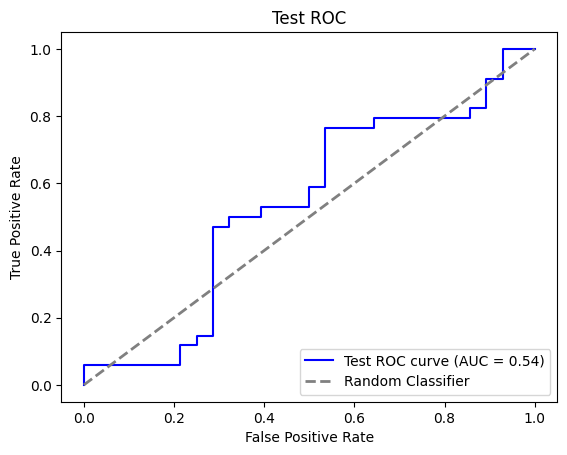

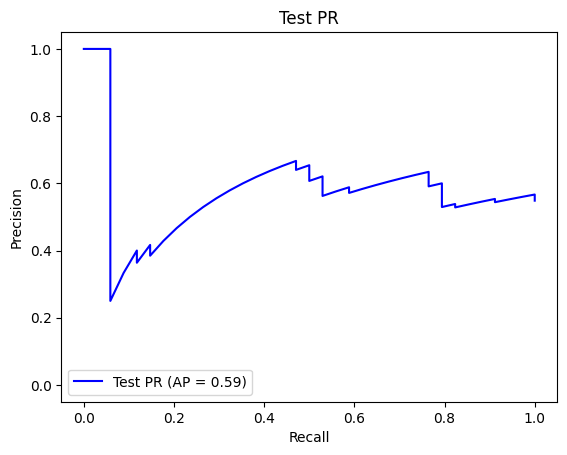

************ Test Results ************
F1 Score: 0.57
Precision Score: 0.65
Recall Score: 0.50
Specificity: 0.68
Balanced Accuracy Score: 0.59
AUC: 0.54
AP: 0.59
Confusion Matrix:
 [[19  9]
 [17 17]]
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.68      0.59        28
           1       0.65      0.50      0.57        34

    accuracy                           0.58        62
   macro avg       0.59      0.59      0.58        62
weighted avg       0.60      0.58      0.58        62



In [10]:
# Final held-out test evaluation using best parameters (LOF outlier removal)
pipeline.set_params(
    oversampling__k_neighbors=best_params[0],
    clf__C=best_params[1],
    clf__gamma=best_params[2]
)
train_inliers = LOF_OutlierDetection(X_train)
X_train_inliers = X_train[train_inliers]
y_train_inliers = y_train[train_inliers]
pipeline.fit(X_train_inliers, y_train_inliers)

y_test_pred = pipeline.predict(X_test)
y_test_scores = pipeline.decision_function(X_test)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_precision = precision_score(y_test, y_test_pred, average='binary', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='binary', zero_division=0)
test_specificity = recall_score(y_test, y_test_pred, average='binary', zero_division=0, pos_label=0)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred)
test_ap = average_precision_score(y_test, y_test_scores)

fpr, tpr, _ = roc_curve(y_test, y_test_scores)
test_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='b', label='Test ROC curve (AUC = {:.2f})'.format(test_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Classifier')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC')
plt.legend(loc='lower right')
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_test_scores)
plt.plot(recall, precision, color='b', label='Test PR (AP = {:.2f})'.format(test_ap))
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Test PR')
plt.legend(loc='lower left')
plt.show()

print("************ Test Results ************")
print(f"F1 Score: {test_f1:.2f}")
print(f"Precision Score: {test_precision:.2f}")
print(f"Recall Score: {test_recall:.2f}")
print(f"Specificity: {test_specificity:.2f}")
print(f"Balanced Accuracy Score: {test_balanced_accuracy:.2f}")
print(f"AUC: {test_auc:.2f}")
print(f"AP: {test_ap:.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred, zero_division=0))